In [1]:
#Importing modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

  h values    Forward   Backward    Central Five Point      Exact
  0.500000   0.063449   0.529153   0.296301   0.308392   0.309017
  0.200000   0.212172   0.401750   0.306961   0.309001   0.309017
  0.100000   0.260989   0.356015   0.308502   0.309016   0.309017
  0.050000   0.285117   0.332660   0.308888   0.309017   0.309017
  0.020000   0.299486   0.318507   0.308996   0.309017   0.309017
  0.010000   0.304257   0.313767   0.309012   0.309017   0.309017
  0.005000   0.306638   0.311393   0.309016   0.309017   0.309017
  0.002000   0.308066   0.309968   0.309017   0.309017   0.309017
  0.001000   0.308541   0.309492   0.309017   0.309017   0.309017
  0.000500   0.308779   0.309255   0.309017   0.309017   0.309017
  0.000200   0.308922   0.309112   0.309017   0.309017   0.309017
  0.000100   0.308969   0.309065   0.309017   0.309017   0.309017
Forward Slope ---> 1.0
Backward Slope ---> 0.99
Central Slope ---> 2.0
Five Point Slope ---> 4.01


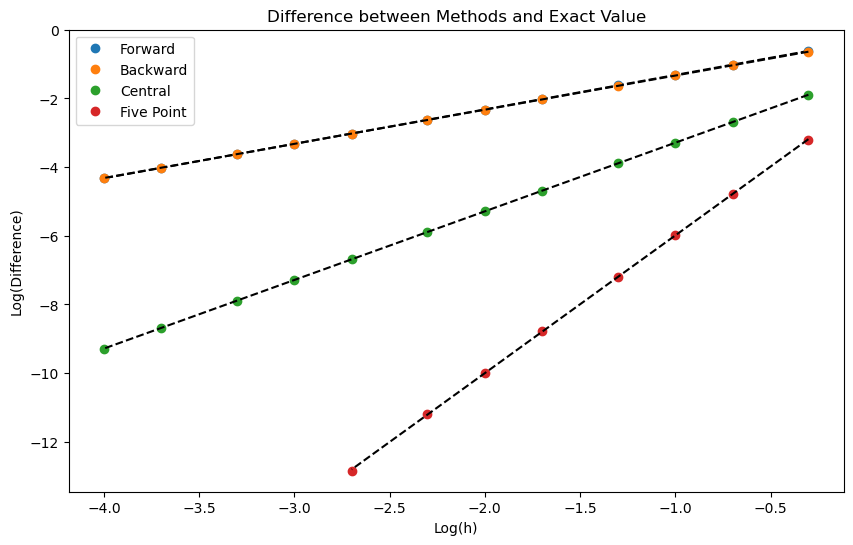

In [2]:
#Q1

#defining the functions
def f(x):
    return np.sin(x)

def forward_diff(f,x,h):
    return (f(x + h) - f(x))/h

def backward_diff(f,x,h):
    return (f(x) - f(x - h))/h

def central_diff(f,x,h):
    return (f(x + h) - f(x - h))/(2*h)

def fivepoint_diff(f,x,h):
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h))/(12*h)

def line(x,m,c):
    return m*x + c

x = 2*np.pi/5
exact = np.cos(x)

methods = [forward_diff, backward_diff, central_diff, fivepoint_diff]
h_vals =  [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]
description = ["Forward","Backward","Central","Five Point"]
print("%10s %10s %10s %10s %10s %10s"%("h values","Forward","Backward","Central","Five Point","Exact"))
for h in h_vals:
    print("%10.6f"%(h), end = " ")
    for method in methods:
        print("%10.6f"%(method(f,x,h)), end = " ")
    print("%10.6f"%(exact))
i = 0
fig, ax = plt.subplots(figsize = (10,6))
for method in methods:
    if i == 3:
        y = [abs(method(f,x,h) - exact) for h in h_vals[:8]]
        ax.plot(np.log10(h_vals[:8]), np.log10(y[:8]),"o", label = description[i])
        popt,pcov = curve_fit(line, np.log10(h_vals[:8]), np.log10(y[:8]), p0=[1,1])
        ax.plot(np.log10(h_vals[:8]), line(np.log10(h_vals[:8]),*popt), color = "k", ls = "--")
        print(f"{description[i]} Slope ---> {round(popt[0],2)}")
        i+=1
    else:
        y = [abs(method(f,x,h) - exact) for h in h_vals]
        ax.plot(np.log10(h_vals), np.log10(y),"o", label = description[i])
        popt,pcov = curve_fit(line, np.log10(h_vals), np.log10(y), p0=[1,1])
        ax.plot(np.log10(h_vals), line(np.log10(h_vals),*popt), color = "k", ls = "--")
        print(f"{description[i]} Slope ---> {round(popt[0], 2)}")
        i+=1
plt.legend()
plt.title("Difference between Methods and Exact Value")
plt.xlabel("Log(h)")
plt.ylabel("Log(Difference)")
plt.show()

Using Trapezoid Method --> 1.7197134913893146
Using Simpson's 1/3 Method --> 1.7182827819248239
Using Simpson's 3/8 Method --> 1.7182822522776569
Using Boole's Method --> 1.7182818285157924
       m values       Trapezoid   Simpson's 1/3   Simpson's 3/8         Boole's           Exact
              4      1.72051859      1.71828415      1.71828286      1.71828183      1.71828183
              8      1.71884113      1.71828197      1.71828189      1.71828183      1.71828183
             16      1.71842166      1.71828184      1.71828183      1.71828183      1.71828183
             32      1.71831679      1.71828183      1.71828183      1.71828183      1.71828183
             64      1.71829057      1.71828183      1.71828183      1.71828183      1.71828183
Trapezoid Slope ---> -2.0
Simpson's 1/3 Slope ---> -4.0
Simpson's 3/8 Slope ---> -4.0
Boole's Slope ---> -4.94


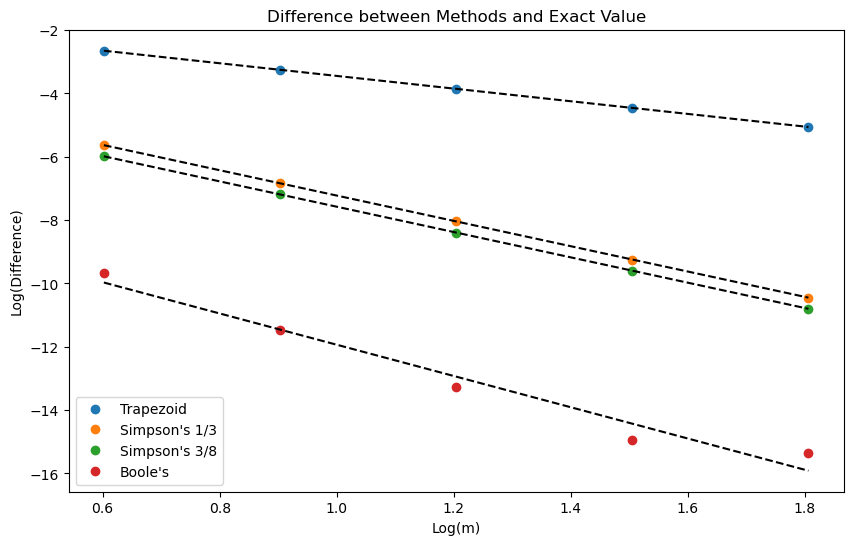

In [22]:
#Q2
#defining the functions
def exp(x):
    return np.exp(x)

def trapezoid(f,x_o,x_n, m):
  N = 2*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (h*(2*np.sum(f(x)) - f(x[0]) - f(x[-1]))/2)

def quadratic(f,x_o,x_n, m):
  N = 2*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (h*(f(x[0]) + f(x[-1]) + 4*np.sum(f(x[1:-1:2])) + 2*np.sum(f(x[2:-1:2])))/3)

def cubic(f,x_o,x_n, m):
  N = 3*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (3*h*(f(x[0]) + f(x[-1]) + 3*np.sum(f(x[1:-1])) - np.sum(f(x[3:-1:3])))/8)

def boole(f,x_o,x_n, m):
  N = 4*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (2*h*(7*(f(x[0]) + f(x[-1])) + 32*np.sum(f(x[1:-1:2])) + 12*np.sum(f(x[2:-1:4])) + 14*np.sum(f(x[4:-1:4])))/45)

#printing the value of the integration of exponential function using different methods
print(f"Using Trapezoid Method --> {trapezoid(exp,0,1,5)}")
print(f"Using Simpson's 1/3 Method --> {quadratic(exp,0,1,5)}")
print(f"Using Simpson's 3/8 Method --> {cubic(exp,0,1,5)}")
print(f"Using Boole's Method --> {boole(exp,0,1,5)}")

exact = (np.exp(1) - 1)
x_0 = 0
x_N = 1
methods = [trapezoid, quadratic, cubic, boole]
m_vals =  [4, 8, 16, 32, 64]
description = ["Trapezoid", "Simpson's 1/3", "Simpson's 3/8", "Boole's"]
print("%15s %15s %15s %15s %15s %15s"%("m values","Trapezoid", "Simpson's 1/3", "Simpson's 3/8", "Boole's", "Exact"))
for m in m_vals:
    print("%15.f"%(m), end = " ")
    for method in methods:
        print("%15.8f"%(method(exp,x_0,x_N,m)), end = " ")
    print("%15.8f"%(exact))
i = 0
fig, ax = plt.subplots(figsize = (10,6))
for method in methods:
        y = [abs(method(exp,x_0,x_N,m) - exact) for m in m_vals]
        ax.plot(np.log10(m_vals), np.log10(y),"o", label = description[i])
        popt,pcov = curve_fit(line, np.log10(m_vals), np.log10(y), p0=[1,1])
        ax.plot(np.log10(m_vals), line(np.log10(m_vals),*popt), color = "k", ls = "--")
        print(f"{description[i]} Slope ---> {round(popt[0], 2)}")
        i+=1
plt.legend()
plt.title("Difference between Methods and Exact Value")
plt.xlabel("Log(m)")
plt.ylabel("Log(Difference)")
plt.show()

In [25]:
#Q3

def f(x):
    return (x**(-2/3))*((1 - x)**(-1/3)) #has singularities at x = 0, and x = 1

def cubic(f,x_o,x_n, m):
    N = 3*m + 1
    x = np.linspace(x_o,x_n,N)
    h = x[1] - x[0]
    return (3*h*(f(x[0]) + f(x[-1]) + 3*np.sum(f(x[1:-1])) - np.sum(f(x[3:-1:3])))/8)

#We split the integral from 0 to 0.5 and 0.5 to 1
#For integration in the first half we make substitution p^3 = x, and for the second half we do p^2/3 = 1 - x, 
#and get respective functions f1 and f2, along with the proper limits of integration.

def f1(p):
    return 3*((1 - p**3)**(-1/3))

def f2(p):
    return 3*((1 - p**(3/2))**(-2/3))/2

x0 = 0
x1 = 0.5**(1/3)
x2 = 0.5**(2/3)

print(f"Vale after integrating using Simpson's 3/8 method --> {cubic(f1,x0,x1,50) + cubic(f2,x0,x2,50)}")
print(f"Exact value of integral --> {2*np.pi/np.sqrt(3)}")

Vale after integrating using Simpson's 3/8 method --> 3.6275987568712433
Exact value of integral --> 3.6275987284684357
